## VOL REGIME

In [ ]:
import sys
from pathlib import Path

# Repo root: walk up from notebook file (Cursor) and/or kernel cwd
_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb":
        p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate
            break
    if ROOT is not None:
        break
if ROOT is None:
    raise FileNotFoundError(
        "Open the Signal_Monitor folder in Cursor, then re-run. "
        f"Could not find vol_surface.py from notebook={_nb!r} cwd={Path.cwd()!r}"
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from volatility_regime import HMMVolatilityRegime

spx_model = HMMVolatilityRegime.from_market("SPX", signal_mode=True)
nsq_model = HMMVolatilityRegime.from_market("NSDQ", signal_mode=True)
dji_model = HMMVolatilityRegime.from_market("DJI", signal_mode=True)

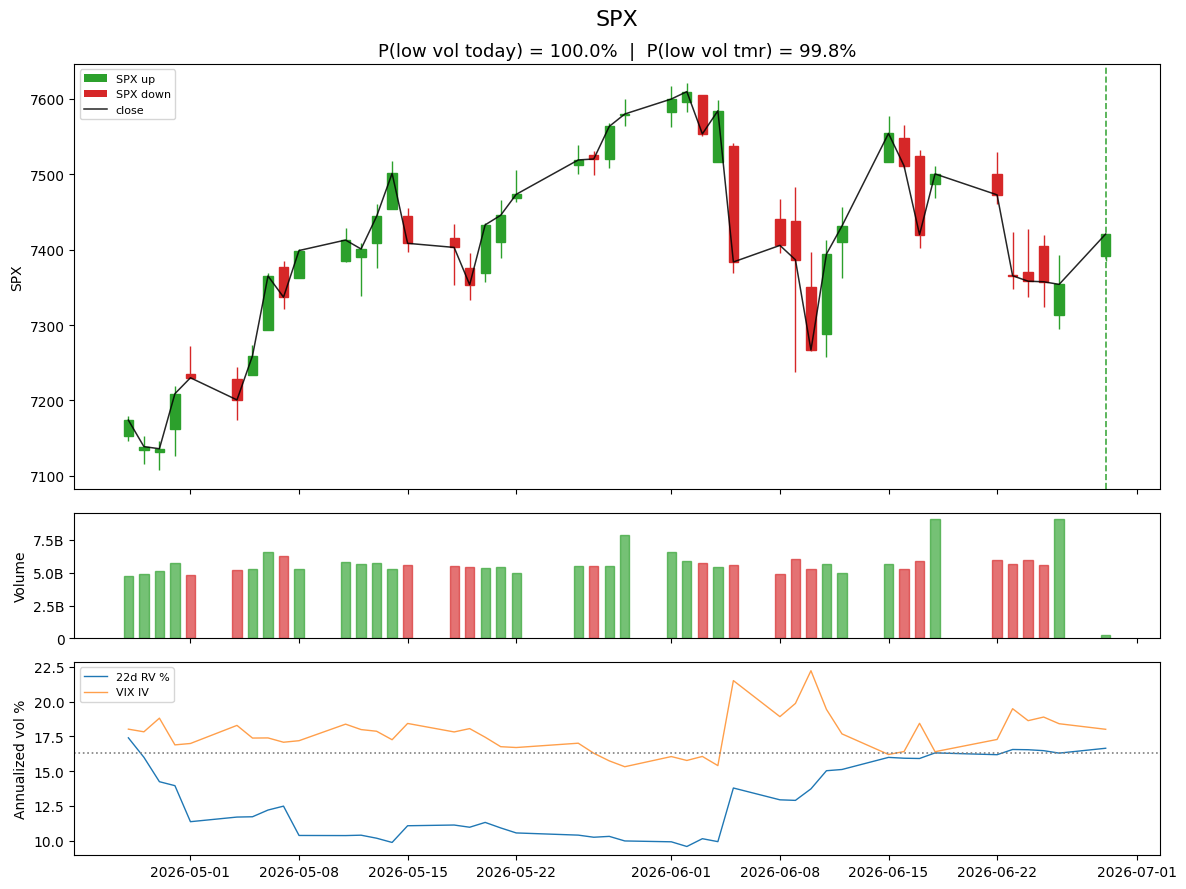


SPX implied vs realized move (1σ)
Spot = 7,421 | IV = 18.0% | 1d hist: avg |move| last 22d
Horizon | Implied   | Historical | Spot ± implied
--------+-----------+------------+---------------
1d      | 84(1.1%)  | 57(0.8%)   | 7,337 | 7,505 
15d     | 326(4.4%) | 296(4.0%)  | 7,095 | 7,747 
22d     | 395(5.3%) | 365(4.9%)  | 7,026 | 7,816 
30d     | 461(6.2%) | 391(5.3%)  | 6,960 | 7,882 


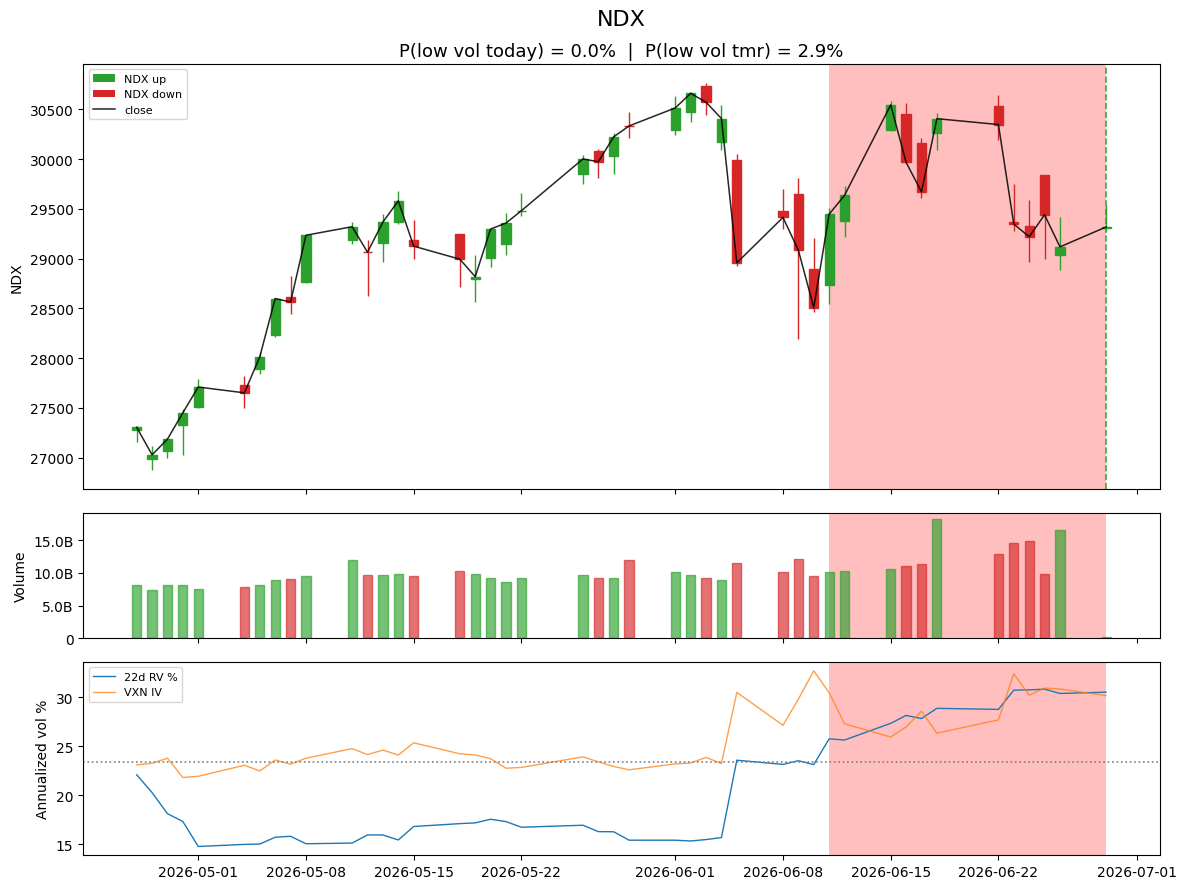


NDX implied vs realized move (1σ)
Spot = 29,322 | IV = 30.1% | 1d hist: avg |move| last 22d
Horizon | Implied     | Historical  | Spot ± implied 
--------+-------------+-------------+----------------
1d      | 557(1.9%)   | 419(1.4%)   | 28,765 | 29,879
15d     | 2,156(7.4%) | 2,187(7.5%) | 27,166 | 31,478
22d     | 2,611(8.9%) | 2,642(9.0%) | 26,711 | 31,933
30d     | 3,049(10%)  | 2,776(9.5%) | 26,273 | 32,371


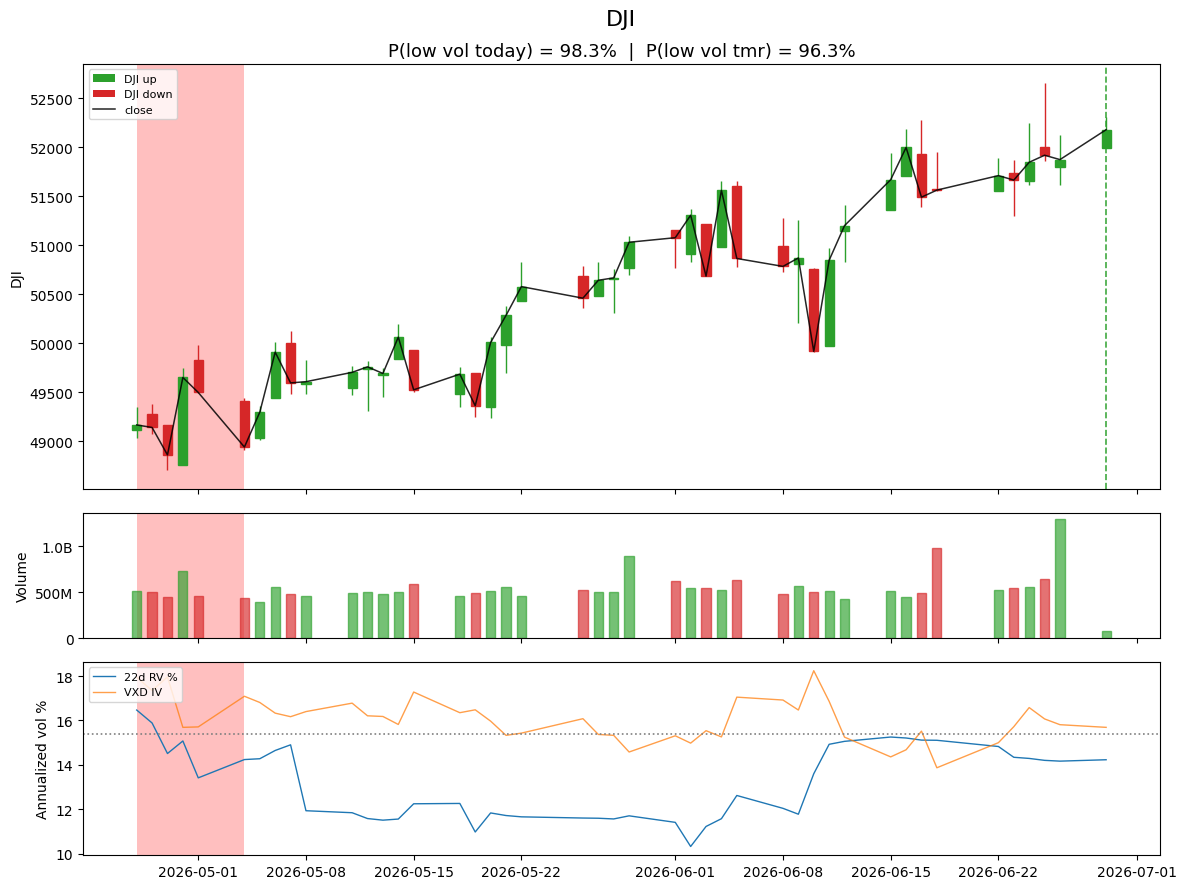


DJI implied vs realized move (1σ)
Spot = 52,177 | IV = 15.7% | 1d hist: avg |move| last 22d
Horizon | Implied     | Historical  | Spot ± implied 
--------+-------------+-------------+----------------
1d      | 516(1.0%)   | 345(0.7%)   | 51,662 | 52,693
15d     | 1,997(3.8%) | 1,697(3.3%) | 50,180 | 54,175
22d     | 2,419(4.6%) | 2,194(4.2%) | 49,758 | 54,596
30d     | 2,825(5.4%) | 2,427(4.7%) | 49,353 | 55,002


In [ ]:
spx_model.display(display_period=44)
nsq_model.display(display_period=44)
dji_model.display(display_period=44)

## VOl Surface

In [1]:
# 1. Setup + fetch data
import sys, warnings
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb": p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate; break
    if ROOT: break
if not ROOT: raise FileNotFoundError("Open Signal_Monitor in Cursor.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(mpl.rcParamsDefault)

from vol_surface import VolSurfaceConfig, VolSurfaceStudy, latest_business_session
from surface_sentiment import SurfaceDeltaPCA, SurfacePCAConfig
from data_fetcher import RateLimiter, SafeFetchSession

# Define the target underlying index ticker: "US..SPX", "US..IXIC" (Nasdaq), or "US..DJI" (Dow Jones)
UNDERLYING_TICKER = "US..SPX"

cfg = VolSurfaceConfig(underlying=UNDERLYING_TICKER, max_dte=60, lookback_days=15)

# If other index tickers are targeted and local cache folder doesn't exist yet, 
# load_history using use_demo_if_empty=True will automatically load full simulation option matrices on the fly
try:
    import futu as ft
    limiter = RateLimiter(600)
    session = SafeFetchSession(limiter, cfg)
    ctx = ft.OpenQuoteContext(host=cfg.host, port=cfg.port)
    df = session.fetch_and_cache(ctx, max_retries=3)
    ctx.close()
    print(f"Live: {len(df)} contracts")
except Exception as e:
    print(f"Live failed: {e}, using demo/synthetic curves for {UNDERLYING_TICKER}")
    df = None

study = VolSurfaceStudy(cfg)
study.load_history(use_demo_if_empty=True) # Enabled demo simulation fallback for NDX/DJI
dates = sorted(study.surfaces.keys())
print(f"Loaded {len(dates)} sessions for {UNDERLYING_TICKER}")
print(dates[0].strftime("%Y-%m-%d"), "->", dates[-1].strftime("%Y-%m-%d"))

2026-07-04 17:07:08,079 | 24984 | 19948 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479098461192171640(1) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000001AE35B179E0>
Live: 7438 contracts
2026-07-04 17:07:46,261 | 24984 | 32416 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(1) reason=CallClose
Loaded 6 sessions for US..SPX
2026-06-22 -> 2026-07-02


2026-07-04 17:08:06,251 | 24984 | 32416 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(2) reason=CallClose


In [2]:
# 2. Run analysis + PCA

result = study.analyze()
today_f = result["today"]

pca = SurfaceDeltaPCA(SurfacePCAConfig(n_components=4, baseline_window=21))
pca_result = pca.fit(surfaces=study.surfaces)
evr = pca_result["explained_variance_ratio"]

hist_scores = pca_result["score_history"]
score_dates = pca_result["score_dates"]
composite = -(hist_scores[:, 0] / np.nanstd(hist_scores[:, 0])
              + hist_scores[:, 1] / np.nanstd(hist_scores[:, 1]))

print(f"PCA: PC1={evr[0]:.1%} PC2={evr[1]:.1%} PC3={evr[2]:.1%}")
today_scores = hist_scores[-1]
sentiment = pca.sentiment_from_scores(today_scores, hist_scores)
print(f"Today: z_PC1={today_scores[0]:+.2f} z_PC2={today_scores[1]:+.2f}")

2026-07-04 17:08:02,659 | 24984 | 19948 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479098690118181725(2) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000001AE372ADA30>


Not enough valid rolling delta-surfaces (0) to fit PCA components (4) or StandardScale safely. Falling back to 'prev' (day-over-day change).


PCA: PC1=60.2% PC2=39.1% PC3=0.6%
Today: z_PC1=+8.10 z_PC2=-13.68


In [ ]:
# 3. Bloomberg-style 3D vol surface with IV/local vol toggle (using Moneyness K/S)

# Encapsulating the Plotly 3D visual rendering
fig = study.plot_bloomberg_3d_surface()
fig.show()

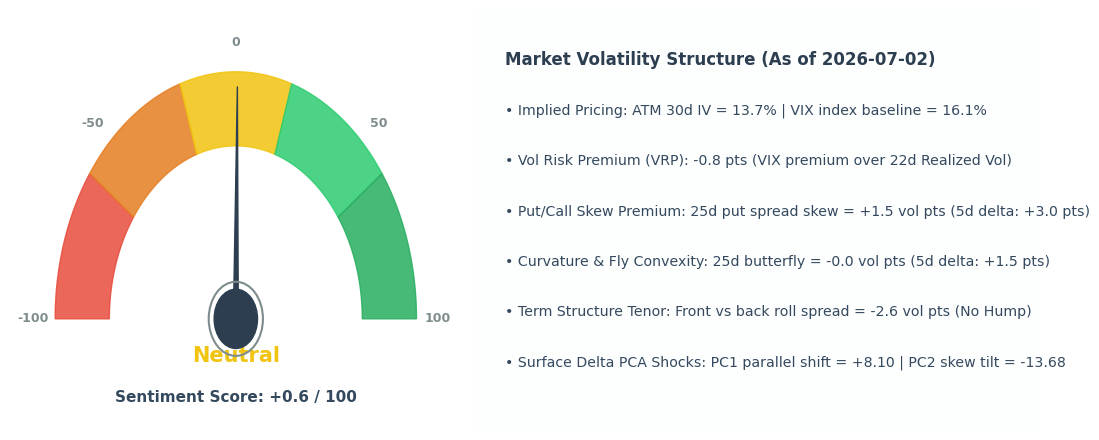

In [ ]:
# 4. Compass Gauge Speedometer (Bull / Bear) & Sentiment Summary Bulletpoints

# Direct call to the encapsulated dual-panel speedometer plot
study.plot_sentiment_gauge(result=result, today_scores=today_scores, sentiment=sentiment)